## Missing Users Data Issue

    This dataset is skewed towards, the users who has longer study participation duration on the platform. 

    Some users turned off the sensors entirely or It seems like sensor permission issue or some users did not carry their phone continuously with them or user stopped using application or user dropped from the clinical study survey or user did not comply for the study.
    
    e.g., at what percentage of the users are missing at least these xx days? So, this will help us drop the less users (as they are not getting the data from them. ), and the percentage of the users that we might drop from the dataset will be much more lower and reasonable.


In [33]:

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go


import os
import tempfile

import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.distributions.empirical_distribution import ECDF

from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)


In [34]:
def pd_read_parquet(artifact_path: str) -> pd.DataFrame:
    '''
    This function should read a Parquet file located at the provided path and return a pandas DataFrame.
    '''
    return pd.read_parquet(artifact_path)

path = 'data (1).parquet'
df = pd_read_parquet(path)
df.head()

,user_id,ts,active_time_m7,active_time_m14,active_time_s7,active_time_s14,activity_percent_m7,activity_percent_m14,activity_percent_s7,activity_percent_s14,...,phq_q4,phq_q5,phq_q6,phq_q7,phq_q8,phq_q9,phq2_total,phq8_total,phq9_total,deployment
0,us-east-1:1b087523-b47b-421c-97c4-74da80564598,2018-09-25 18:17:26.647,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,0.0,1.0,1.0,1.0,NaN,3.0,9.0,NaN,hr-rct-cue-1
1,us-east-1:ea986d8e-e87d-458b-a798-1999fbbff05b,2018-09-26 17:13:52.394,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,3.0,3.0,3.0,NaN,4.0,21.0,NaN,hr-rct-cue-1
2,us-east-1:8dfca9b6-22b6-4155-8a70-ce3e1211a684,2018-09-27 19:04:15.124,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,3.0,3.0,1.0,NaN,6.0,22.0,NaN,hr-rct-cue-1
3,us-east-1:77f43bb4-fe8e-4a50-a4fc-41bc14b11f9d,2018-10-01 22:01:32.622,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,1.0,2.0,2.0,0.0,NaN,2.0,10.0,NaN,hr-rct-cue-1
4,us-east-1:4940dfa3-1c01-49f2-9cdd-029291d7b7a8,2018-10-05 21:08:52.441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.0,3.0,3.0,1.0,0.0,NaN,6.0,18.0,NaN,hr-rct-cue-1


In [35]:
#print the shape of the dataset.
print(df.shape)
print('Count of rows:', df.shape[0])
print('Count of columns:', df.shape[1])

(6820, 158)
Count of rows: 6820
Count of columns: 158


In [36]:
df.deployment.value_counts()

deployment
hr-ascent-1      2924
hr-uchealth-1    1512
hr-internal-1    1031
hr-rct-ctrl-1     700
hr-rct-cue-1      653
Name: count, dtype: int64

In [37]:
# For stakeholders: Filter the dataset to include only the 'hr-ascent-1' deployment
df = df[df.deployment == 'hr-ascent-1']
df.head()

,user_id,ts,active_time_m7,active_time_m14,active_time_s7,active_time_s14,activity_percent_m7,activity_percent_m14,activity_percent_s7,activity_percent_s14,...,phq_q4,phq_q5,phq_q6,phq_q7,phq_q8,phq_q9,phq2_total,phq8_total,phq9_total,deployment
0,us-east-1:db841a21-c4fd-cf09-4379-5af0b6185e0e,2024-03-23 21:58:52.242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,2.0,3.0,3.0,1.0,6.0,23.0,24.0,hr-ascent-1
1,us-east-1:db841a21-c48b-cd1c-563f-eb23aa6c2768,2024-03-26 14:46:43.386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,1.0,2.0,2.0,1.0,5.0,19.0,20.0,hr-ascent-1
2,us-east-1:db841a21-c46a-c6fd-ca13-1faabac2c46d,2024-03-27 16:19:40.526,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,1.0,1.0,1.0,1.0,0.0,4.0,12.0,12.0,hr-ascent-1
3,us-east-1:db841a21-c4b2-c6b9-91ed-370b2da2aa86,2024-03-27 16:42:15.485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.0,3.0,2.0,3.0,1.0,1.0,6.0,21.0,22.0,hr-ascent-1
4,us-east-1:db841a21-c438-c76a-5078-c47a75e6b0c3,2024-03-28 14:52:36.017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,1.0,1.0,0.0,2.0,7.0,7.0,hr-ascent-1


In [38]:
#print the shape of the dataset.
print(df.shape)
print('Count of rows:', df.shape[0])
print('Count of columns:', df.shape[1])

(2924, 158)
Count of rows: 2924
Count of columns: 158


In [39]:
df.user_id.nunique()

601

In [40]:
df.isna().sum().sort_values(ascending=False).head(30)

school                     2924
occupation                 2924
chronotype                 2924
sleep_end_m14              2411
sleep_end_s14              2411
sleep_start_s14            2411
sleep_interruptions_s14    2411
sleep_duration_m14         2411
sleep_duration_s14         2411
sleep_start_m14            2411
sleep_interruptions_m14    2411
full_time                  2138
sleep_start_m7             2133
sleep_interruptions_s7     2133
sleep_interruptions_m7     2133
sleep_end_m7               2133
sleep_end_s7               2133
sleep_duration_s7          2133
sleep_duration_m7          2133
sleep_start_s7             2133
travel_diameter_m14        1494
travel_diameter_s14        1494
time_at_location_5_s14     1428
time_at_location_5_m14     1428
time_at_location_4_s14     1322
time_at_location_4_m14     1322
travel_diameter_m7         1300
travel_diameter_s7         1300
walking_rate_m14           1291
walking_rate_s14           1291
dtype: int64

In [41]:
df.groupby('deployment').sleep_duration_m7.apply(lambda x: x.isnull().mean())

deployment
hr-ascent-1    0.72948
Name: sleep_duration_m7, dtype: float64

In [42]:
df.groupby('deployment').occupation.apply(lambda x: x.isnull().mean())

deployment
hr-ascent-1    1.0
Name: occupation, dtype: float64

In [43]:
df.groupby('deployment').total_activity_duration_m7.apply(lambda x: x.isnull().mean())

deployment
hr-ascent-1    0.185705
Name: total_activity_duration_m7, dtype: float64

In [44]:
df.groupby('deployment').sleep_duration_m7.apply(lambda x: x.isnull().mean())

deployment
hr-ascent-1    0.72948
Name: sleep_duration_m7, dtype: float64

In [45]:
df.groupby('deployment').sleep_duration_m7.apply(lambda x: x.isnull().mean())

deployment
hr-ascent-1    0.72948
Name: sleep_duration_m7, dtype: float64

In [46]:
[col for col in df.columns if 0 < df[col].isna().sum() < len(df)]


['active_time_m7',
 'active_time_m14',
 'active_time_s7',
 'active_time_s14',
 'activity_percent_m7',
 'activity_percent_m14',
 'activity_percent_s7',
 'activity_percent_s14',
 'chronotype_score_m7',
 'chronotype_score_m14',
 'chronotype_score_s7',
 'chronotype_score_s14',
 'display_events_m7',
 'display_events_m14',
 'display_events_s7',
 'display_events_s14',
 'ec_Activity_m7',
 'ec_Activity_m14',
 'ec_Activity_s7',
 'ec_Activity_s14',
 'ec_DeviceDisplayStatus_m7',
 'ec_DeviceDisplayStatus_m14',
 'ec_DeviceDisplayStatus_s7',
 'ec_DeviceDisplayStatus_s14',
 'ec_Location_m7',
 'ec_Location_m14',
 'ec_Location_s7',
 'ec_Location_s14',
 'ec_PedometerData_m7',
 'ec_PedometerData_m14',
 'ec_PedometerData_s7',
 'ec_PedometerData_s14',
 'ec_total_m7',
 'ec_total_m14',
 'ec_total_s7',
 'ec_total_s14',
 'time_at_location_1_m7',
 'time_at_location_1_m14',
 'time_at_location_1_s7',
 'time_at_location_1_s14',
 'time_at_location_2_m7',
 'time_at_location_2_m14',
 'time_at_location_2_s7',
 'time_at

Missing days distribution per user:
count    601.000000
mean       0.974249
std        0.102657
min        0.333333
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: missing_proportion, dtype: float64


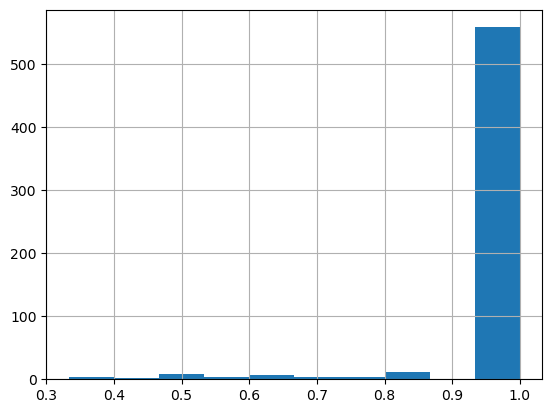

In [52]:
# Identify sensor-related columns (excluding fully missing/complete columns)
sensor_cols = [col for col in df.columns if 0 < df[col].isna().sum() < len(df)]

# Flag days with any missing sensor data
df['any_missing'] = df[sensor_cols].isnull().any(axis=1)

# Calculate missing proportion per user
missing_per_user = df.groupby('user_id')['any_missing'].agg(['sum', 'count'])

missing_per_user['missing_proportion'] = missing_per_user['sum'] / missing_per_user['count']


# Display distribution
print("Missing days distribution per user:")
print(missing_per_user['missing_proportion'].describe())

# Plot histogram
missing_per_user['missing_proportion'].hist()
plt.show()